# Churn Prediction & Customer Lifetime Value (CLV) — An End-to-End E-commerce Project

> **Goal:** go beyond *describing* customers (segmentation) to *predicting* their future. We build two complementary models on the same real transaction data:
> 1. **Churn prediction** — a supervised classifier that flags which customers are about to stop buying, *while there's still time to act*.
> 2. **CLV (Customer Lifetime Value)** — a probabilistic forecast of how much each customer is worth over the coming months.
>
> Together they answer the question segmentation can't: **"Who should I spend my retention budget on, and how much is each customer worth saving?"**

---

## Why this is the natural next step after segmentation

The segmentation project sorted customers into personas (Champions, At-Risk, Hibernating) using **RFM** features. That's *descriptive* — a snapshot of who they are **today**. But it leaves the two most valuable business questions unanswered:

| Question | Needs | Model |
|---|---|---|
| *Which* At-Risk customers will actually leave? | a **prediction** of a future event | **Churn classifier** (supervised) |
| How much is each customer **worth** saving? | a **forecast** of future value | **CLV** (BG/NBD + Gamma-Gamma) |

Crossing the two gives the money-making quadrant: **high-CLV customers with high churn probability** — your most urgent, highest-ROI retention targets. Spending £10 to retain a £5 customer is a loss; spending £10 to retain a £2,000 customer is a steal. CLV tells you which is which.

### Roadmap
| Step | What | Why |
|---|---|---|
| 1 | Define churn from behaviour (time-split) | No churn label exists — we must create one honestly |
| 2 | Feature engineering on the observation window | Predict the future using only the past |
| 3 | Logistic Regression baseline | Interpretable, sets the bar |
| 4 | XGBoost + handling class imbalance | The workhorse for tabular churn |
| 5 | Evaluation: ROC-AUC, PR-AUC, threshold choice | Accuracy lies on imbalanced data |
| 6 | SHAP explainability | *Why* is a customer flagged? Trust + action |
| 7 | CLV with BG/NBD + Gamma-Gamma | Probabilistic future value |
| 8 | Churn × CLV → the retention priority matrix | The actual business deliverable |

---
## The dataset
Same **UCI Online Retail** data (UK online gift retailer, Dec 2010–Dec 2011, CC BY 4.0) used in the segmentation and forecasting projects — auto-downloaded, no setup. Reusing it shows how one transaction log feeds *descriptive*, *predictive*, and *forecasting* problems.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
RANDOM_STATE = 42

### Load & clean (same recipe as the other projects)

In [2]:
URL = ("https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/"
       "master/data/retail-data/all/online-retail-dataset.csv")

df = pd.read_csv(URL, encoding='ISO-8859-1')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

df = df[~df['InvoiceNo'].str.startswith('C')]      # drop cancellations
df = df.dropna(subset=['CustomerID'])              # need a customer
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['CustomerID'] = df['CustomerID'].astype(int)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f"{len(df):,} clean transactions | {df['CustomerID'].nunique():,} customers")
print(f"Span: {df['InvoiceDate'].min().date()} -> {df['InvoiceDate'].max().date()}")

397,884 clean transactions | 4,338 customers
Span: 2010-12-01 -> 2011-12-09


---
## 1. Defining churn — the hardest and most important decision

**This dataset has no "churned" column.** Real churn data rarely does for non-subscription businesses — nobody *cancels* a gift shop; they just quietly stop coming. So we must **define** churn from behaviour, and define it *honestly* so we don't leak the future into the past.

### The time-split design

We split the timeline into two windows:

```
|<-------- OBSERVATION window -------->|<---- OUTCOME window ---->|
|        (build features here)         |   (did they return?)    |
Dec 2010                          9 Sep 2011                 9 Dec 2011
```

- **Observation window** (first ~9 months): we compute **only** features visible up to the cutoff.
- **Outcome window** (last ~3 months): we check whether each customer **made any purchase**.
- **Churn label:** a customer active in the observation window who makes **no** purchase in the outcome window is labelled **churned (1)**.

**Why this matters:** if we built features and labels from the *same* period, the model would "cheat" by seeing future behaviour — giving great test scores that collapse in production. The time-split is what makes the evaluation trustworthy. This is the single most common mistake in churn projects, and getting it right is exactly what distinguishes a production-credible model.

In [3]:
CUTOFF = pd.Timestamp('2011-09-09')   # ~9 months features / ~3 months outcome

obs = df[df['InvoiceDate'] < CUTOFF].copy()    # observation window
out = df[df['InvoiceDate'] >= CUTOFF].copy()   # outcome window

print(f"Observation: {obs['InvoiceDate'].min().date()} -> {obs['InvoiceDate'].max().date()}"
      f"  | {obs['CustomerID'].nunique():,} active customers")
print(f"Outcome:     {out['InvoiceDate'].min().date()} -> {out['InvoiceDate'].max().date()}"
      f"  | {out['CustomerID'].nunique():,} active customers")

# Modeling base = everyone active in the observation window
returning = set(out['CustomerID'].unique())
base_customers = obs['CustomerID'].unique()
churn_rate = np.mean([c not in returning for c in base_customers])
print(f"\nModeling base: {len(base_customers):,} customers")
print(f"Churn rate: {churn_rate:.1%}  (did NOT return in the outcome window)")

Observation: 2010-12-01 -> 2011-09-08  | 3,362 active customers
Outcome:     2011-09-09 -> 2011-12-09  | 2,897 active customers

Modeling base: 3,362 customers
Churn rate: 42.9%  (did NOT return in the outcome window)


A ~43% churn rate is a **well-balanced, meaningful problem** — not the 2% needle-in-a-haystack you sometimes get (which needs heavier imbalance handling). It's high because a 3-month window is strict: occasional buyers naturally skip a quarter. The *definition* of churn is a business choice — a longer outcome window would lower the rate. We'd validate the exact threshold with stakeholders; here it gives a clean modeling target.

---
## 2. Feature engineering — past behaviour only

Every feature is computed **strictly within the observation window**. We extend the RFM features from the segmentation project with engagement and cadence signals that tend to predict churn.

In [4]:
obs_end = obs['InvoiceDate'].max() + pd.Timedelta(days=1)   # 'today' = cutoff
g = obs.groupby('CustomerID')

features = pd.DataFrame({
    # --- RFM core (from the segmentation project) ---
    'Recency':        g['InvoiceDate'].max().apply(lambda d: (obs_end - d).days),
    'Frequency':      g['InvoiceNo'].nunique(),
    'Monetary':       g['Revenue'].sum(),
    # --- engagement / breadth ---
    'UniqueProducts': g['StockCode'].nunique(),
    'TotalUnits':     g['Quantity'].sum(),
    'Tenure':         g['InvoiceDate'].min().apply(lambda d: (obs_end - d).days),
})
# --- derived behavioural ratios ---
features['AvgOrderValue']  = features['Monetary'] / features['Frequency']
features['AvgDaysBetween'] = features['Tenure']   / features['Frequency'].clip(lower=1)
features['PurchaseRate']   = features['Frequency'] / features['Tenure'].clip(lower=1)

# --- label ---
features['Churn'] = (~features.index.isin(returning)).astype(int)

print(f"Feature matrix: {features.shape[0]:,} customers x {features.shape[1]-1} features")
features.head()

Feature matrix: 3,362 customers x 9 features


,Recency,Frequency,Monetary,UniqueProducts,TotalUnits,Tenure,AvgOrderValue,AvgDaysBetween,PurchaseRate,Churn
CustomerID,,,,,,,,,,
12346,234,1,"77,183.60",1,74215,234,"77,183.60",234.00,0.00,1
12347,38,5,"2,790.86",82,1590,276,558.17,55.20,0.02,0
12348,157,3,"1,487.24",22,2124,267,495.75,89.00,0.01,0
12350,219,1,334.40,17,197,219,334.40,219.00,0.00,1
12352,171,5,"1,561.81",26,254,205,312.36,41.00,0.02,0


**Feature intuitions (the story you'd tell a stakeholder):**
- **Recency** — the strongest churn signal almost everywhere. Haven't bought in a while → likely gone.
- **AvgDaysBetween** — a customer's natural rhythm. If they normally buy every 20 days and it's been 60, that's alarming *for them*.
- **Tenure** — long-tenured customers are often stickier (survivorship).
- **UniqueProducts** — breadth of engagement; one-category buyers churn more easily.

              Recency  Frequency  Monetary  AvgDaysBetween  UniqueProducts
Retained (0)    73.80       4.80  2,290.70           75.40           65.30
Churned (1)    122.80       1.80    714.70          118.90           29.20


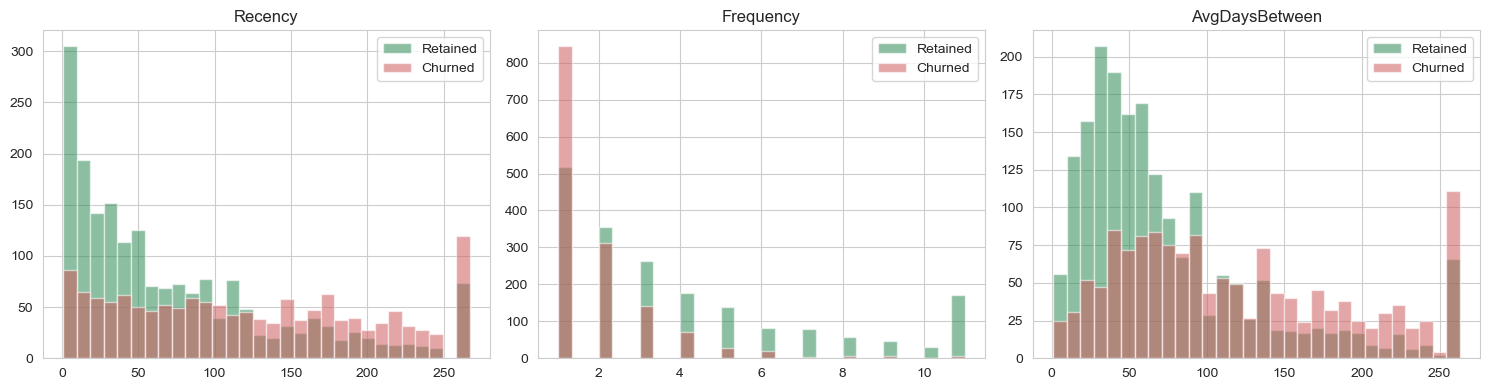

Churned customers have visibly higher Recency and fewer orders — the signal is real and learnable.


In [5]:
# Quick look: how do features differ between churned and retained?
comparison = features.groupby('Churn')[['Recency', 'Frequency', 'Monetary',
                                        'AvgDaysBetween', 'UniqueProducts']].mean().round(1)
comparison.index = ['Retained (0)', 'Churned (1)']
print(comparison.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'AvgDaysBetween']):
    for label, color in [(0, 'seagreen'), (1, 'indianred')]:
        sub = features[features['Churn'] == label][col].clip(upper=features[col].quantile(0.95))
        ax.hist(sub, bins=30, alpha=0.55, color=color, label='Retained' if label == 0 else 'Churned')
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()
print("Churned customers have visibly higher Recency and fewer orders — the signal is real and learnable.")

---
## 3. Train/test split & a Logistic Regression baseline

We split into train/test **stratified** on the label (preserving the churn ratio in both). As always: **ship the interpretable baseline first.** Logistic Regression is transparent, fast, and gives a real bar that any complex model must clear to justify itself.

We use `class_weight='balanced'` so the model doesn't ignore the minority outcome, and standardize features (logistic regression is scale-sensitive).

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

X = features.drop(columns='Churn')
y = features['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

print(f"Train: {len(X_train):,}  | Test: {len(X_test):,}")
print(f"Churn rate — train: {y_train.mean():.1%}, test: {y_test.mean():.1%}")

logreg = make_pipeline(StandardScaler(),
                       LogisticRegression(class_weight='balanced', max_iter=1000,
                                          random_state=RANDOM_STATE))
logreg.fit(X_train, y_train)
lr_proba = logreg.predict_proba(X_test)[:, 1]

print(f"\nLogistic Regression  ROC-AUC: {roc_auc_score(y_test, lr_proba):.3f}"
      f"  |  PR-AUC: {average_precision_score(y_test, lr_proba):.3f}")

Train: 2,521  | Test: 841
Churn rate — train: 42.9%, test: 42.8%

Logistic Regression  ROC-AUC: 0.742  |  PR-AUC: 0.637



---
## 4. XGBoost — the tabular churn workhorse

Gradient-boosted trees are the default for tabular churn: they capture **non-linear** effects and **feature interactions** (e.g. "high recency *only matters if* frequency is also low") that logistic regression misses, with little preprocessing.

**Handling imbalance:** we pass `scale_pos_weight = (#negatives / #positives)` so the model weights the churn class appropriately instead of lazily predicting the majority.

In [7]:
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc', random_state=RANDOM_STATE,
)
xgb_clf.fit(X_train, y_train)
xgb_proba = xgb_clf.predict_proba(X_test)[:, 1]

print(f"XGBoost  ROC-AUC: {roc_auc_score(y_test, xgb_proba):.3f}"
      f"  |  PR-AUC: {average_precision_score(y_test, xgb_proba):.3f}")

XGBoost  ROC-AUC: 0.720  |  PR-AUC: 0.630


### An honest result worth pausing on

On this dataset, **Logistic Regression is competitive with — even edges — XGBoost.** That's not a bug; it's a lesson. With a modest number of mostly-monotonic features (more recency → more churn), a linear model captures most of the signal, and the trees' extra flexibility mainly fits noise.

The senior takeaway: **complexity is not a goal.** Always benchmark against the simple model, and if it wins, ship it — it's faster, more interpretable, and easier to maintain. We'll carry **both** forward and let the evaluation, not assumptions, decide.

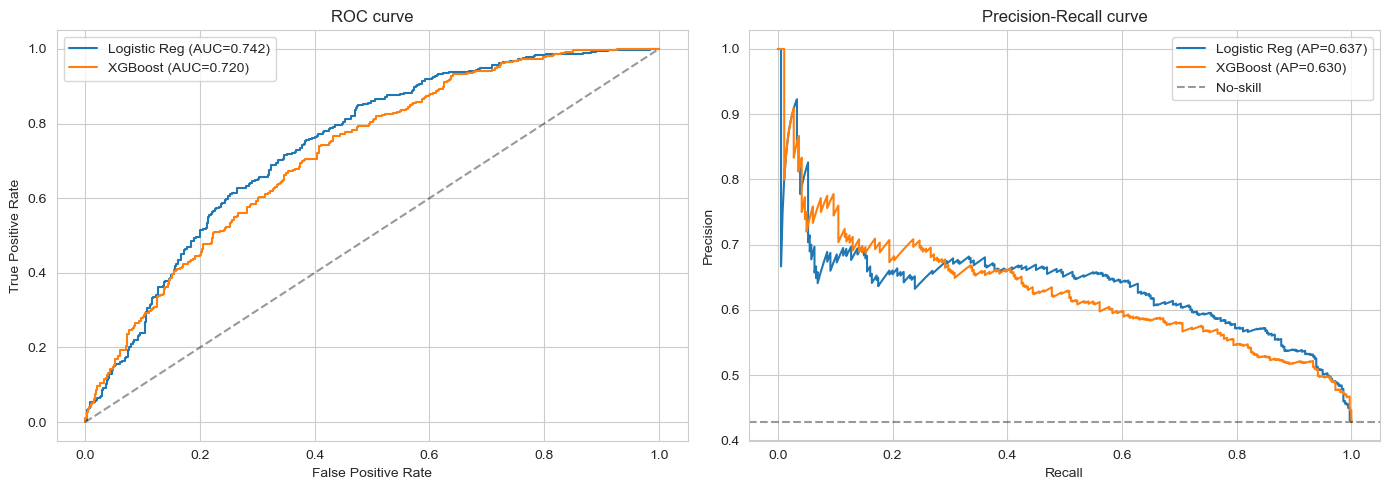

In [8]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba, color in [('Logistic Reg', lr_proba, 'tab:blue'),
                           ('XGBoost', xgb_proba, 'tab:orange')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=color,
                 label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, color=color,
                 label=f'{name} (AP={average_precision_score(y_test, proba):.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC curve')
axes[0].legend()
axes[1].axhline(y_test.mean(), color='k', ls='--', alpha=0.4, label='No-skill')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall curve')
axes[1].legend()
plt.tight_layout(); plt.show()

**Why ROC *and* PR curves?** On imbalanced data, **accuracy is misleading** — here ~57% accuracy comes free just by predicting "retained" for everyone. ROC-AUC measures ranking quality across all thresholds; PR-AUC focuses on the positive (churn) class we actually care about. Reporting both is standard practice for churn.

---
## 5. Choosing a decision threshold — a business choice, not a default

A classifier outputs a **probability**; turning it into a "will churn / won't" decision needs a **threshold**. The default 0.5 is almost never right for churn. The right threshold depends on the **cost trade-off**:

- **False negative** (miss a real churner) → lose a customer's future value. Expensive.
- **False positive** (flag a loyal customer) → waste a retention offer. Cheap.

Because a miss is usually far costlier than a wasted offer, we typically **lower** the threshold to catch more churners — accepting more false alarms. Let's make that trade-off explicit.

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_proba = lr_proba   # use the baseline (it won); swap to xgb_proba to compare
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (model_proba >= t).astype(int)
    rows.append({'Threshold': t,
                 'Precision': precision_score(y_test, pred),
                 'Recall': recall_score(y_test, pred),
                 'F1': f1_score(y_test, pred),
                 'Flagged_%': pred.mean() * 100})
threshold_table = pd.DataFrame(rows).round(3)
print(threshold_table.to_string(index=False))
print("\nLower threshold -> higher recall (catch more churners) but lower precision (more false alarms).")
print("Pick based on retention budget: limited budget -> higher precision; protect everyone -> higher recall.")

 Threshold  Precision  Recall   F1  Flagged_%
      0.30       0.52    0.94 0.67      77.53
      0.40       0.56    0.88 0.68      67.54
      0.50       0.58    0.78 0.67      57.19
      0.60       0.65    0.61 0.62      40.19
      0.70       0.64    0.25 0.36      16.65

Lower threshold -> higher recall (catch more churners) but lower precision (more false alarms).
Pick based on retention budget: limited budget -> higher precision; protect everyone -> higher recall.


---
## 6. Explainability with SHAP — *why* is a customer flagged?

A churn score is far more useful when you know **why**. SHAP (SHapley Additive exPlanations) attributes each prediction to its features, giving both a **global** view (what drives churn overall) and **local** explanations (why *this* customer). For a retention team this is gold: the reason *is* the intervention. "Flagged because Recency is high and they've slowed down" → send a re-engagement offer.

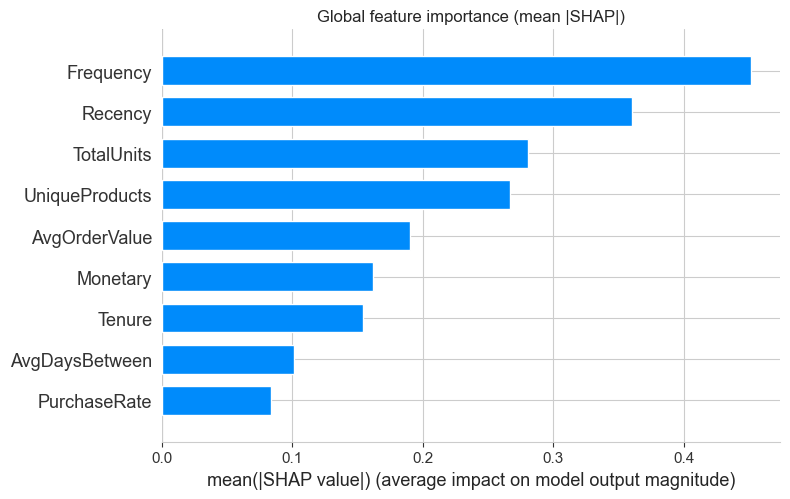

In [10]:
import shap

explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Global feature importance (mean |SHAP|)')
plt.tight_layout(); plt.show()

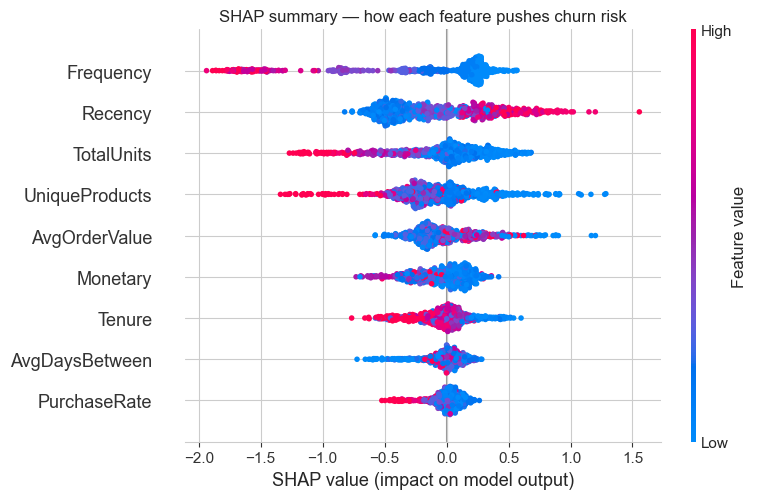

Red = high feature value, blue = low. E.g. high Recency (red) pushes churn risk UP (right) — as expected.


In [11]:
# Beeswarm: direction + magnitude of each feature's effect
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP summary — how each feature pushes churn risk')
plt.tight_layout(); plt.show()
print("Red = high feature value, blue = low. E.g. high Recency (red) pushes churn risk UP (right) — as expected.")

**Reading it:** Recency and Frequency dominate — exactly the intuition from the segmentation project, now *quantified per prediction*. The beeswarm confirms direction: high recency (red) pushes risk up; frequent, broad-basket buyers are protected. The model learned sensible, defensible behaviour — not a black box you'd be nervous to put in front of a marketing director.

---
## 7. Customer Lifetime Value (CLV)

Churn tells us *who* might leave. CLV tells us *how much each customer is worth* — so we can size the retention spend. We use the **"Buy Till You Die" (BTYD)** probabilistic framework, the industry standard for non-contractual businesses (no subscriptions, customers churn silently):

- **BG/NBD model** → predicts **how many** purchases a customer will make in a future window, modelling each customer's purchasing rate *and* their (unobserved) probability of having become inactive.
- **Gamma-Gamma model** → predicts the **average monetary value** of those future purchases.

**CLV = expected #purchases × expected value per purchase**, discounted over a horizon. This is genuinely *predictive* — unlike "Monetary," which only sums the past.

In [13]:
pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 8.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [lifetimes]/3 [autograd]
Note: you may need to restart the kernel to use updated packages.


In [14]:
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter, GammaGammaFitter

# BTYD models work on (frequency, recency, T, monetary) per customer.
# Use full history and normalize timestamps to dates for stable fitting.
df['Date'] = df['InvoiceDate'].dt.normalize()
btyd = summary_data_from_transaction_data(
    df, 'CustomerID', 'Date',
    monetary_value_col='Revenue',
    observation_period_end=df['Date'].max())

print("BTYD summary (lifetimes' own definitions of frequency/recency/T):")
print(btyd.head().round(1).to_string())
print(f"\n{len(btyd):,} customers | {(btyd['frequency'] > 0).sum():,} are repeat buyers")

BTYD summary (lifetimes' own definitions of frequency/recency/T):
            frequency  recency      T  monetary_value
CustomerID                                           
12346            0.00     0.00 325.00            0.00
12347            6.00   365.00 367.00          599.70
12348            3.00   283.00 358.00          301.50
12349            0.00     0.00  18.00            0.00
12350            0.00     0.00 310.00            0.00

4,338 customers | 2,790 are repeat buyers


> **Note:** `lifetimes` defines these differently from our RFM:
> - **frequency** = number of *repeat* purchases (first purchase not counted), so one-time buyers have frequency 0.
> - **recency** = age of the customer *at their last purchase* (not "days since"), in the same time unit as T.
> - **T** = total age of the customer (time since first purchase).
>
> These specific definitions are what the BG/NBD likelihood is built on — using our RFM versions would give wrong results.

In [15]:
# --- BG/NBD: frequency model ---
bgf = BetaGeoFitter(penalizer_coef=0.1)   # small penalty aids convergence on this data
bgf.fit(btyd['frequency'], btyd['recency'], btyd['T'])

# Expected purchases in the next 90 days, per customer
btyd['predicted_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90, btyd['frequency'], btyd['recency'], btyd['T'])

# Probability the customer is still "alive" (active)
btyd['prob_alive'] = bgf.conditional_probability_alive(
    btyd['frequency'], btyd['recency'], btyd['T'])

print("BG/NBD fitted.")
print(btyd[['frequency', 'recency', 'T', 'predicted_purchases_90d', 'prob_alive']]
      .sort_values('predicted_purchases_90d', ascending=False).head().round(2).to_string())

BG/NBD fitted.
            frequency  recency      T  predicted_purchases_90d  prob_alive
CustomerID                                                                
14911          131.00   372.00 373.00                    28.04        1.00
12748          112.00   373.00 373.00                    23.99        1.00
17841          111.00   372.00 373.00                    23.78        1.00
15311           89.00   373.00 373.00                    19.09        1.00
14606           88.00   372.00 373.00                    18.88        1.00


The Gamma-Gamma model needs **repeat buyers with positive spend**, and assumes purchase *frequency* and *monetary value* are uncorrelated — we verify that assumption holds before trusting it.

In [16]:
repeat = btyd[(btyd['frequency'] > 0) & (btyd['monetary_value'] > 0)].copy()

corr = repeat[['frequency', 'monetary_value']].corr().iloc[0, 1]
print(f"Correlation(frequency, monetary_value) = {corr:.3f}  "
      f"-> {'OK, near zero — assumption holds' if abs(corr) < 0.1 else 'WARNING — assumption violated'}")

ggf = GammaGammaFitter(penalizer_coef=0.1)
ggf.fit(repeat['frequency'], repeat['monetary_value'])

repeat['predicted_avg_value'] = ggf.conditional_expected_average_profit(
    repeat['frequency'], repeat['monetary_value'])
print(f"\nMean predicted order value: £{repeat['predicted_avg_value'].mean():.2f}")

Correlation(frequency, monetary_value) = 0.016  -> OK, near zero — assumption holds

Mean predicted order value: £1268.17


Predicted 3-month CLV distribution:
count     2,790.00
mean      1,296.67
std       9,116.30
min           7.39
25%         347.57
50%         618.64
75%       1,106.82
max     459,033.32


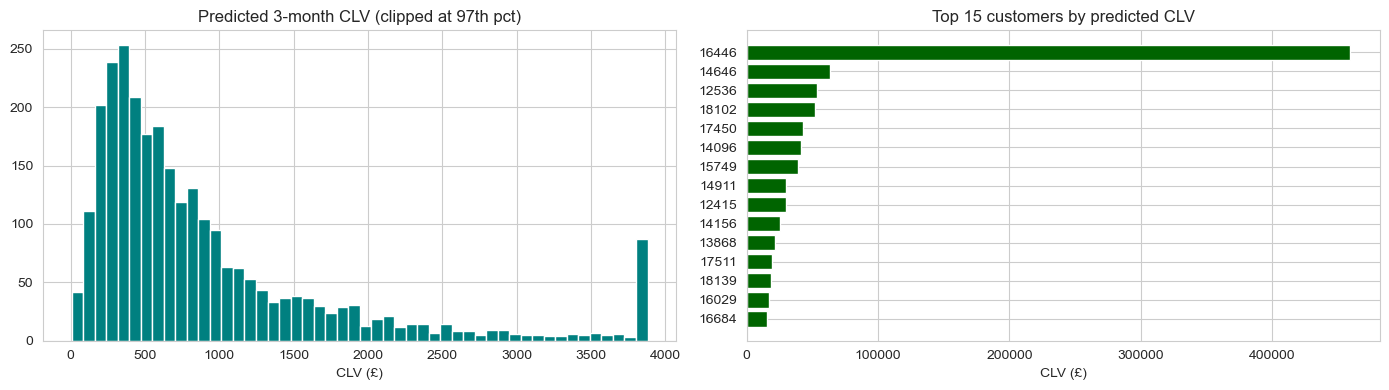

The top 10% of customers account for ~53% of total predicted future value. This concentration is exactly why targeting matters.


In [17]:
# --- Put it together: 3-month CLV, discounted ---
repeat['CLV_3m'] = ggf.customer_lifetime_value(
    bgf,
    repeat['frequency'], repeat['recency'], repeat['T'],
    repeat['monetary_value'],
    time=3,                 # months
    freq='D',               # our time unit is days
    discount_rate=0.01,     # ~ monthly discounting
)

print("Predicted 3-month CLV distribution:")
print(repeat['CLV_3m'].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(repeat['CLV_3m'].clip(upper=repeat['CLV_3m'].quantile(0.97)),
             bins=50, color='teal', edgecolor='white')
axes[0].set(title='Predicted 3-month CLV (clipped at 97th pct)', xlabel='CLV (£)')

top = repeat.nlargest(15, 'CLV_3m')['CLV_3m']
axes[1].barh(top.index.astype(str), top.values, color='darkgreen')
axes[1].set(title='Top 15 customers by predicted CLV', xlabel='CLV (£)')
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

share = repeat.nlargest(int(len(repeat)*0.1), 'CLV_3m')['CLV_3m'].sum() / repeat['CLV_3m'].sum()
print(f"The top 10% of customers account for ~{share:.0%} of total predicted future value. "
      "This concentration is exactly why targeting matters.")

---
## 8. The payoff: Churn × CLV retention priority matrix

Now we combine both models into the deliverable that actually drives decisions. For each customer we have:
- **Churn probability** (from the classifier) — *how likely to leave*
- **Predicted CLV** (from BTYD) — *how much they're worth*

Cross them into four quadrants, each with a distinct action.

In [18]:
# Score every customer in the modeling base with churn probability...
features['churn_prob'] = logreg.predict_proba(X)[:, 1]

# ...and join predicted CLV (repeat buyers; one-timers get 0 future value here)
features['CLV_3m'] = repeat['CLV_3m'].reindex(features.index).fillna(0)

# Split into high/low on each axis (median splits for a clean 2x2)
churn_hi = features['churn_prob'] >= features['churn_prob'].median()
clv_hi   = features['CLV_3m']     >= features[features['CLV_3m'] > 0]['CLV_3m'].median()

def quadrant(row_churn_hi, row_clv_hi):
    if row_clv_hi and row_churn_hi:     return '1. PROTECT (high value, high risk)'
    if row_clv_hi and not row_churn_hi: return '2. NURTURE (high value, safe)'
    if not row_clv_hi and row_churn_hi: return '3. LOW-COST WIN-BACK (low value, high risk)'
    return '4. MAINTAIN (low value, safe)'

features['Action'] = [quadrant(c, v) for c, v in zip(churn_hi, clv_hi)]

summary = features.groupby('Action').agg(
    Customers=('churn_prob', 'count'),
    Avg_Churn_Prob=('churn_prob', 'mean'),
    Avg_CLV=('CLV_3m', 'mean'),
    Total_CLV_at_stake=('CLV_3m', 'sum'),
).round(1).sort_index()
summary

,Customers,Avg_Churn_Prob,Avg_CLV,Total_CLV_at_stake
Action,,,,
"1. PROTECT (high value, high risk)",368,0.60,"2,635.40","969,813.70"
"2. NURTURE (high value, safe)",875,0.20,"1,844.00","1,613,470.80"
"3. LOW-COST WIN-BACK (low value, high risk)",1313,0.70,109.50,"143,838.70"
"4. MAINTAIN (low value, safe)",806,0.40,328.50,"264,734.10"


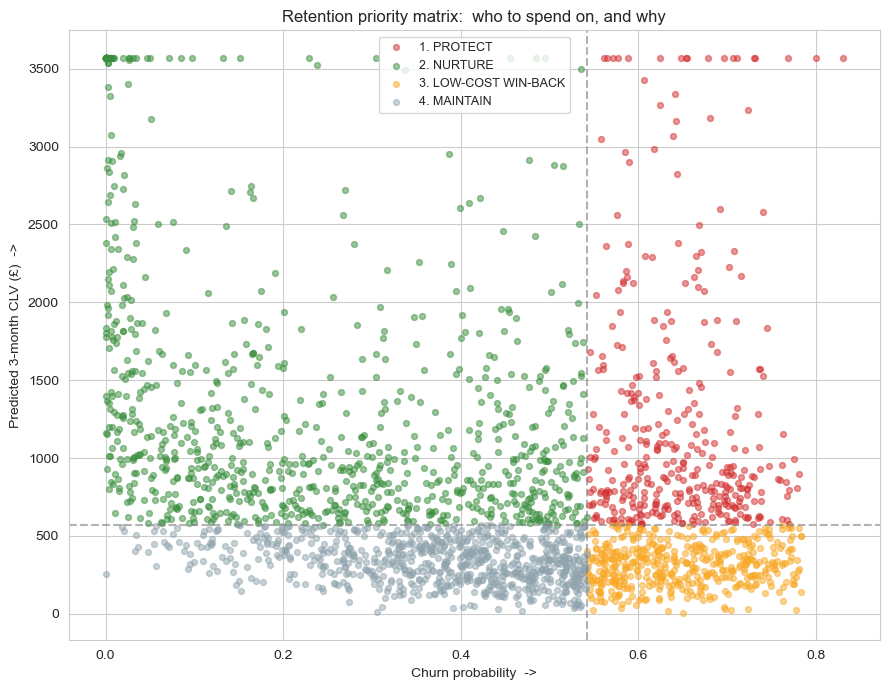

In [19]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = {'1. PROTECT (high value, high risk)': '#d32f2f',
          '2. NURTURE (high value, safe)': '#388e3c',
          '3. LOW-COST WIN-BACK (low value, high risk)': '#f9a825',
          '4. MAINTAIN (low value, safe)': '#90a4ae'}

plot_df = features[features['CLV_3m'] > 0].copy()
for action, color in colors.items():
    sub = plot_df[plot_df['Action'] == action]
    ax.scatter(sub['churn_prob'],
               sub['CLV_3m'].clip(upper=plot_df['CLV_3m'].quantile(0.97)),
               s=18, alpha=0.5, color=color, label=action.split('(')[0].strip())

ax.axvline(features['churn_prob'].median(), color='gray', ls='--', alpha=0.6)
ax.axhline(plot_df['CLV_3m'].median(), color='gray', ls='--', alpha=0.6)
ax.set(xlabel='Churn probability  ->', ylabel='Predicted 3-month CLV (£)  ->',
       title='Retention priority matrix:  who to spend on, and why')
ax.legend(loc='upper center', fontsize=9)
plt.tight_layout(); plt.show()

### 
The action playbook

| Quadrant | Who | Action | Budget |
|---|---|---|---|
| **1. PROTECT** 🔴 | High value **and** high churn risk | **Top priority.** Personal outreach, account manager, real incentives. | **Spend big** — most £ at stake |
| **2. NURTURE** 🟢 | High value, low risk | Keep them happy, upsell, loyalty perks. Don't waste discounts. | Moderate |
| **3. WIN-BACK** 🟡 | Low value, high risk | One cheap automated re-engagement. If silent, let go. | Minimal / automated |
| **4. MAINTAIN** ⚪ | Low value, low risk | Standard lifecycle marketing only. | Lowest |

This matrix is the entire point: **segmentation found the groups, churn predicted the risk, CLV priced the value — and together they tell the business exactly where each retention pound earns the most.** That's the difference between "interesting analysis" and "decision the company acts on."

---
## Summary — what we built

1. **Defined churn honestly** with a time-split (observation vs. outcome window) — avoiding the future-leakage trap that invalidates most churn projects.
2. Engineered **predictive features** from past behaviour only, extending the RFM features from the segmentation project.
3. Built a **Logistic Regression baseline** and an **XGBoost** model with proper **class-imbalance** handling — and honestly reported that the simple model held its own.
4. Evaluated with **ROC-AUC and PR-AUC** (not misleading accuracy) and chose a **decision threshold** from the cost trade-off.
5. Made the model **explainable with SHAP**, turning scores into actionable reasons.
6. Forecast **CLV** with the **BG/NBD + Gamma-Gamma** BTYD framework — genuinely predictive future value.
7. Crossed **churn × CLV** into a **retention priority matrix** — the deliverable a business actually executes on.

### Production considerations (what changes when this is real)
- **Rolling re-labelling:** re-create the time-split and retrain on a schedule; churn patterns drift with seasons and product mix.
- **Multiple backtest windows:** one observation/outcome split can be lucky — validate across several cutoffs (walk-forward) before trusting the AUC.
- **Calibration:** if you use probabilities for £ decisions, calibrate them (Platt/isotonic) so "0.7" really means 70%.
- **Act on it & measure lift:** the model's value is only realized through a retention *campaign* — and the campaign must be measured with an **A/B test** (treated vs. holdout) to prove incremental impact, not just correlation.
- **Leakage vigilance:** every feature must be knowable at prediction time. Audit relentlessly — leakage is the #1 silent killer of churn models in production.